In [1]:
import napari
from skimage import data, measure
import pandas as pd
import numpy as np

from napari.utils import nbscreenshot

In [2]:
viewer = napari.Viewer()

In [3]:
n_samples = 24
loc = 5
length = 32

In [4]:

# make some random points with random  features
points = np.random.random((n_samples, 2))*length
points2 = np.random.random((n_samples-1, 2))*length

features = pd.DataFrame({
    'feature1': np.random.normal(size=n_samples, loc=loc),
    'feature2': np.random.normal(size=n_samples, loc=loc),
    'feature3': np.random.normal(size=n_samples, loc=loc),
    'feature4': np.random.normal(size=n_samples, loc=loc),})

features2 = pd.DataFrame({
    'feature2': np.random.normal(size=n_samples-1, loc=-loc),
    'feature3': np.random.normal(size=n_samples-1, loc=-loc),
    'feature4': np.random.normal(size=n_samples-1, loc=-loc),})

layer = napari.layers.Points(points, features=features, size=5, blending='translucent_no_depth', name='points')
layer2 = napari.layers.Points(points2, features=features2, size=5, translate=(0, length), blending='translucent_no_depth', name='points2', face_color='red')

viewer.add_layer(layer)
viewer.add_layer(layer2)

<Points layer 'points2' at 0x152dedeb2f0>

In [5]:
binary_image = data.binary_blobs(length=length, n_dim=2, volume_fraction=0.05, rng=1)
label_image = measure.label(binary_image)
binary_image2 = data.binary_blobs(length=length, n_dim=2, volume_fraction=0.1, rng=2)
label_image2 = measure.label(binary_image2)
features = pd.DataFrame({
    'feature1': np.random.random(label_image.max() + 1),
    'feature2': np.random.random(label_image.max() + 1),
    'feature3': np.random.random(label_image.max() + 1),
})
features2 = pd.DataFrame({
    'feature1': np.random.random(label_image2.max() + 1),
    'feature2': np.random.random(label_image2.max() + 1),
    'feature5': np.random.random(label_image2.max() + 1),
})

viewer.add_labels(label_image, name='labels', features=features, translate=(0, 2*length))
viewer.add_labels(label_image2, name='labels2', features=features2, translate=(0, 3*length))

<Labels layer 'labels2' at 0x152d1614710>

In [6]:
faces = np.random.randint(0, n_samples, (n_samples, 3))
faces2 = np.random.randint(0, n_samples-1, (n_samples-1, 3))

surface_layer = viewer.add_surface((points, faces), name='surface', translate=(0, 4*length))
surface_layer2 = viewer.add_surface((points2, faces2), name='surface2', translate=(0, 5*length), colormap='magma')

features = pd.DataFrame({
    'feature1': np.random.normal(size=n_samples, loc=loc),
    'feature2': np.random.normal(size=n_samples, loc=loc),
    'feature3': np.random.normal(size=n_samples, loc=loc),
    'feature4': np.random.normal(size=n_samples, loc=loc),})

features2 = pd.DataFrame({
    'feature2': np.random.normal(size=n_samples-1, loc=-loc),
    'feature3': np.random.normal(size=n_samples-1, loc=-loc),
    'feature4': np.random.normal(size=n_samples-1, loc=-loc),})

surface_layer.features = features
surface_layer2.features = features2

In [7]:
n_vertices = 5
shapes = [np.random.random((n_vertices, 2)) * length for _ in range(n_samples)]

viewer.add_shapes(
    shapes,
    shape_type='polygon',
    name='shapes',
    features=pd.DataFrame({
        'feature1': np.random.random(n_samples),
        'feature2': np.random.random(n_samples),
        'feature3': np.random.random(n_samples),
        'feature4': np.random.random(n_samples),
    }),
    translate=(0, 6*length)
)

shapes2 = [np.random.random((n_vertices, 2)) * length for _ in range(n_samples-1)]

viewer.add_shapes(
    shapes2,
    shape_type='path',
    name='shapes2',
    features=pd.DataFrame({
        'feature1': np.random.random(n_samples-1),
        'feature2': np.random.random(n_samples-1),
        'feature3': np.random.random(n_samples-1),
        'feature4': np.random.random(n_samples-1),
    }),
    translate=(0, 7*length)
)

<Shapes layer 'shapes2' at 0x152e540daf0>

In [8]:
n_tracks = 3
n_timepoints = 8
track_ids = np.arange(1, n_tracks + 1).repeat(n_samples//n_tracks)
track_frames = np.tile(np.arange(n_timepoints), n_samples//n_timepoints)
tracks_x = np.linspace(0, length, n_samples, dtype=int)
tracks_y = np.random.random(n_samples) * length
tracks_data = np.stack(
    [track_ids, track_frames, tracks_y, tracks_x]).T

features = pd.DataFrame({
    'frame': track_frames,
    'feature1': np.random.random(n_samples),
    'feature2': np.random.random(n_samples),
    'feature3': np.random.random(n_samples),
    'feature4': np.random.random(n_samples),
})

viewer.add_tracks(
    tracks_data,
    name='tracks',
    features=features,
    translate=(0, 0, 8*length)
)

<Tracks layer 'tracks' at 0x152dfd326f0>

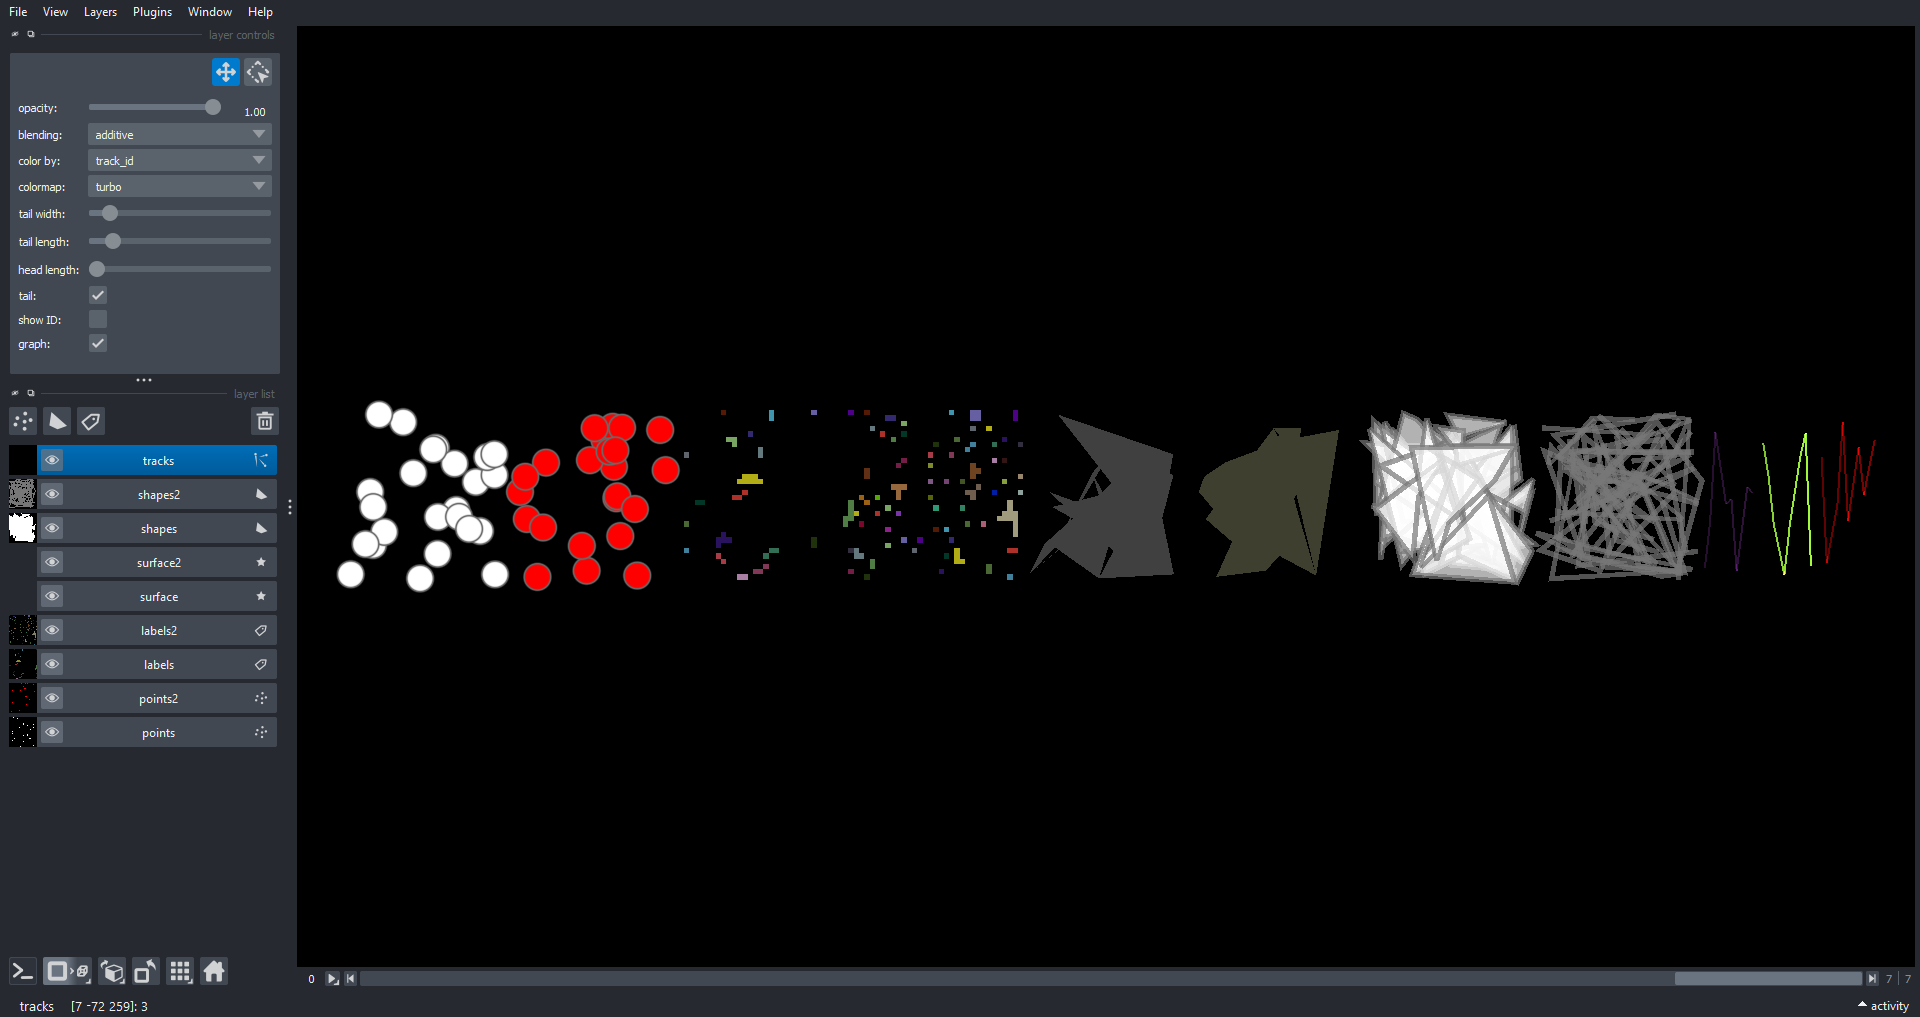

In [10]:
viewer.reset_view()
viewer.dims.current_step = (n_timepoints, 0, 0)

nbscreenshot(viewer)